In [3]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Rutvi\OneDrive\Desktop\Streaming Churn Intelligence Behavioral Segmentation & Retention Analytics\archive (6)\netflix_large_user_data.xlsx")

In [4]:
df_kpi = df.copy()
df_kpi.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [5]:
df = pd.read_csv("feature_engineered_data.csv")


In [6]:
df_kpi['churn_flag'] = df_kpi['Churn Status (Yes/No)'].map({'Yes': 1, 'No': 0})
df_kpi[['Churn Status (Yes/No)', 'churn_flag']].head()


,Churn Status (Yes/No),churn_flag
0,No,0
1,Yes,1
2,Yes,1
3,No,0
4,Yes,1


##  Core Business KPIs

We calculate:
- Total users
- Churn rate
- Retention rate

In [8]:
total_users = len(df_kpi)
churned_users = df_kpi['churn_flag'].sum()
retained_users = total_users - churned_users

churn_rate = churned_users / total_users
retention_rate = retained_users / total_users

print("Total Users:", total_users)
print("Churned Users:", churned_users)
print("Churn Rate:", round(churn_rate, 3))
print("Retention Rate:", round(retention_rate, 3))

Total Users: 1000
Churned Users: 539
Churn Rate: 0.539
Retention Rate: 0.461


## 📌 Insight: Platform Health

- Churn rate represents user loss
- Retention rate represents platform stability

 This is the **core KPI of any subscription business**

In [9]:
avg_engagement = df_kpi['Engagement Rate (1-10)'].mean()
avg_watch_time = df_kpi['Daily Watch Time (Hours)'].mean()

print("Average Engagement:", round(avg_engagement, 2))
print("Average Watch Time:", round(avg_watch_time, 2))

Average Engagement: 5.51
Average Watch Time: 2.83


## 📌 Insight: User Activity

- Engagement shows user interest level
- Watch time shows content consumption behavior

 Together they define platform stickiness

In [10]:
plan_churn = df_kpi.groupby('Subscription Plan')['churn_flag'].mean().sort_values()

plan_churn

Subscription Plan
Standard    0.534091
Premium     0.534954
Basic       0.548589
Name: churn_flag, dtype: float64

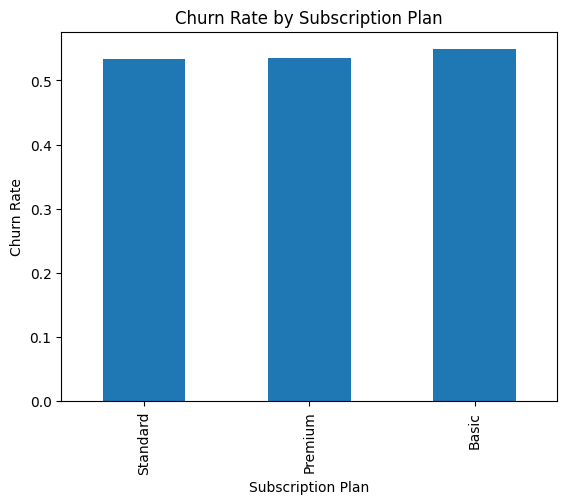

In [11]:
import matplotlib.pyplot as plt

plan_churn.plot(kind='bar')
plt.title("Churn Rate by Subscription Plan")
plt.ylabel("Churn Rate")
plt.show()


## 📌 Insight: Subscription Impact

- Some plans have higher churn rates
- Indicates pricing/value mismatch

This is a key lever for business improvement

In [12]:
support_churn = df_kpi.groupby('Support Queries Logged')['churn_flag'].mean()

support_churn.head()


Support Queries Logged
0    0.521739
1    0.493976
2    0.516854
3    0.529412
4    0.452632
Name: churn_flag, dtype: float64